In [1]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
#filtered_time = pd.read_csv("filtered_time_normalized.csv", index_col=0)
#data_orig = data_orig.loc[filtered_time.index]
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4897, 3)
Next slips shape (4897, 8)
orig shape (5150, 8)


In [3]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

#Finding the parameters that minimize the squared error 
optimization = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)) # sampler ensures Optuna gives the same tuning results which gives reproducability between runs 
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-02-19 13:58:01,326] A new study created in memory with name: no-name-4e966403-112a-41a8-9f74-1eecc24688f6
[I 2026-02-19 13:58:02,143] Trial 0 finished with value: 18067.997831740446 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 18067.997831740446.
[I 2026-02-19 13:58:02,585] Trial 1 finished with value: 18485.858032736385 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 0 with value: 18067.997831740446.
[I 2026-02-19 13:58:03,201] Trial 2 finished with value: 17962.934941961972 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 2 with value: 17962.934941961972.
[I 2026-02-19 13:58:03,633] Trial 3 finished with value: 18290.6383288965 and

Optimal Parameters: {'learning_rate': 0.011615865989246453, 'max_depth': 5, 'subsample': 0.8896896099223679, 'colsample_bytree': 0.8425192044349383}
XGBoost Error: 18158.78246600348
Mean XGBoost Error: 14045.619058912627


1604    62055.0
2241    47415.0
3271    81675.0
693     45660.0
2422    89415.0
         ...   
3709    88725.0
4120    84915.0
1827    39225.0
820     31185.0
4449    87885.0
Name: time_to_next_ev_hr, Length: 980, dtype: float64
[69370.7   52429.016 59227.9   54849.906 61340.55  81008.516 60364.695
 83888.52  58322.996 49496.453 70835.99  54448.22  56898.19  47931.734
 51416.61  54901.523 59674.906 49104.75  60015.598 64869.91  59516.07
 59403.777 69070.61  85994.01  49213.668 63127.617 71747.65  57421.402
 60075.883 53794.54  61576.957 67369.375 58053.973 61004.926 69363.36
 57847.94  57424.957 60577.66  49421.562 58231.684 51298.633 50681.273
 47243.7   53194.227 61277.016 83747.96  61677.633 59708.98  49185.426
 67389.97  46224.992 60247.516 67699.07  71989.766 61835.504 61239.453
 79631.18  82645.55  71091.77  69312.36  69287.766 52974.234 92537.47
 61736.152 50311.957 62837.86  52547.957 65621.17  47913.195 58987.297
 52209.25  52961.48  58362.99  56560.61  37551.668 63579.617 73

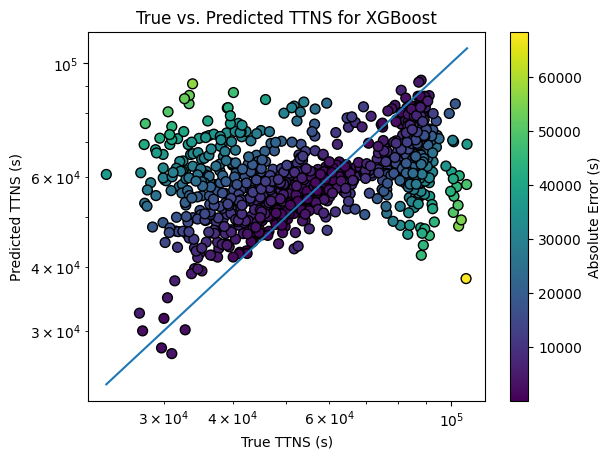

In [4]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
#y_test_secs = y_test.reshape(1,-1)
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction
print(y_test_secs)
print(XG_pred_secs)
absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true}s, Predicted = {pred}s, Error={abs_error}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
plt.xscale('log')
plt.yscale('log')
plt.show()

In [5]:
# Compute absolute errors
print("Length of Subset", len(XG_pred_secs))
diff = np.abs(XG_pred_secs - y_test_secs)

# Threshold for outliers
threshold = 20000  # adjust as needed

# Get indices of outliers in the test set
X_outliers = np.where(diff > threshold)[0]

print("Number of Outliers", len(X_outliers))
print(f"Outliers (error > {threshold}):")

# Print details for only outliers
for idx in X_outliers:
    true = y_test_secs.iloc[idx]   # pandas Series: use iloc
    pred = XG_pred_secs[idx]       # numpy array: use normal indexing
    print(f"Index position {idx}: True={true}, Predicted={pred}")

Length of Subset 980
Number of Outliers 260
Outliers (error > 20000):
Index position 2: True=81675.0, Predicted=59227.8984375
Index position 4: True=89415.0, Predicted=61340.55078125
Index position 15: True=101115.0, Predicted=54901.5234375
Index position 16: True=87000.0, Predicted=59674.90625
Index position 20: True=89624.99999999999, Predicted=59516.0703125
Index position 25: True=40005.0, Predicted=63127.6171875
Index position 26: True=35745.0, Predicted=71747.6484375
Index position 27: True=36765.0, Predicted=57421.40234375
Index position 28: True=89310.0, Predicted=60075.8828125
Index position 30: True=37935.0, Predicted=61576.95703125
Index position 31: True=90675.0, Predicted=67369.375
Index position 44: True=100155.0, Predicted=61277.015625
Index position 46: True=89370.0, Predicted=61677.6328125
Index position 52: True=88410.0, Predicted=67699.0703125
Index position 59: True=30764.999999999996, Predicted=69312.359375
Index position 60: True=33225.0, Predicted=69287.765625
Ind

 96%|=================== | 937/980 [00:21<00:00]       

XG Boost Drivers: tide_height    4173.316430
form_fac       2853.405718
time_since     2351.980402
slip_size      2211.950392
tide_deriv     2121.220768
high_t_evt     1924.707524
dtype: float64


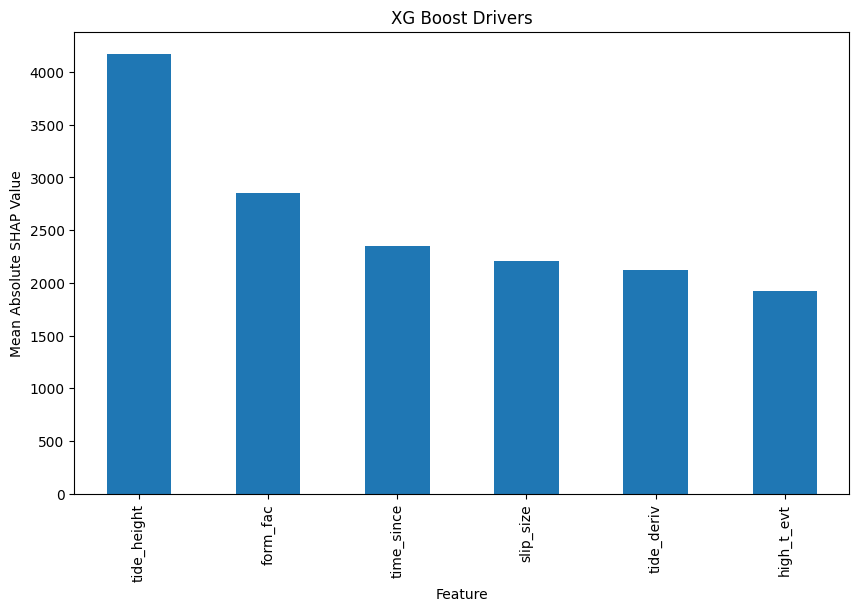

In [6]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
X_shap = pd.DataFrame(X_shap, columns=feature_cols)
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()
